### Practical 9: Recurrent Neural Networks (RNN)

**Title**:
Malware Detection using API Call Sequences

**Objective**:
To classify software as benign or malicious based on sequential API calls using RNN.

In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/ang3loliveira/malware-analysis-datasets-api-call-sequences/dynamic_api_call_sequence_per_malware_100_0_306.csv


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

In [4]:
df = pd.read_csv("/kaggle/input/datasets/ang3loliveira/malware-analysis-datasets-api-call-sequences/dynamic_api_call_sequence_per_malware_100_0_306.csv")
df.head()

,hash,t_0,t_1,t_2,t_3,t_4,t_5,t_6,t_7,t_8,...,t_91,t_92,t_93,t_94,t_95,t_96,t_97,t_98,t_99,malware
0,071e8c3f8922e186e57548cd4c703a5d,112,274,158,215,274,158,215,298,76,...,71,297,135,171,215,35,208,56,71,1
1,33f8e6d08a6aae939f25a8e0d63dd523,82,208,187,208,172,117,172,117,172,...,81,240,117,71,297,135,171,215,35,1
2,b68abd064e975e1c6d5f25e748663076,16,110,240,117,240,117,240,117,240,...,65,112,123,65,112,123,65,113,112,1
3,72049be7bd30ea61297ea624ae198067,82,208,187,208,172,117,172,117,172,...,208,302,208,302,187,208,302,228,302,1
4,c9b3700a77facf29172f32df6bc77f48,82,240,117,240,117,240,117,240,117,...,209,260,40,209,260,141,260,141,260,1


In [5]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43876 entries, 0 to 43875
Columns: 102 entries, hash to malware
dtypes: int64(101), object(1)
memory usage: 34.1+ MB


,t_0,t_1,t_2,t_3,t_4,t_5,t_6,t_7,t_8,t_9,...,t_91,t_92,t_93,t_94,t_95,t_96,t_97,t_98,t_99,malware
count,43876.000000,43876.000000,43876.000000,43876.000000,43876.000000,43876.000000,43876.000000,43876.000000,43876.000000,43876.000000,...,43876.000000,43876.000000,43876.000000,43876.000000,43876.000000,43876.000000,43876.000000,43876.000000,43876.000000,43876.000000
mean,142.830226,211.477414,148.217294,189.045674,187.514746,174.190218,170.290022,199.070015,142.659016,167.358921,...,154.448332,173.219459,159.951568,164.615074,173.637159,152.397848,158.442543,160.717203,155.788199,0.975408
std,75.599441,60.082481,47.667868,68.119087,71.196556,65.713664,55.469501,65.474790,66.756934,53.440972,...,78.342789,82.696235,74.248027,70.240283,70.632812,79.819427,78.142193,74.979008,79.068212,0.154880
min,2.000000,2.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,82.000000,172.000000,117.000000,117.000000,117.000000,117.000000,117.000000,159.000000,117.000000,117.000000,...,81.000000,117.000000,114.000000,117.000000,117.000000,89.000000,100.000000,108.000000,75.250000,1.000000
50%,82.000000,240.000000,158.000000,215.000000,172.000000,158.000000,172.000000,215.000000,117.000000,172.000000,...,141.000000,172.000000,141.000000,171.000000,172.000000,141.000000,171.000000,158.000000,141.000000,1.000000
75%,215.000000,240.000000,172.000000,240.000000,274.000000,240.000000,215.000000,240.000000,208.000000,208.000000,...,240.000000,260.000000,240.000000,215.000000,240.000000,215.000000,224.000000,226.000000,225.000000,1.000000
max,306.000000,306.000000,306.000000,306.000000,306.000000,306.000000,306.000000,306.000000,306.000000,306.000000,...,306.000000,306.000000,306.000000,306.000000,306.000000,306.000000,306.000000,306.000000,306.000000,1.000000


In [6]:
df['malware'].value_counts()

malware
1    42797
0     1079
Name: count, dtype: int64

In [7]:
X = df.drop(["malware", "hash"], axis=1)
y = df["malware"]

Feature Extraction

We separate:
- X → API call sequences
- y → target labels (malware or benign)

In [8]:
# Convert to numeric efficiently
X = X.astype('int32')
y = y.astype('int32')

# Convert to numpy ONLY ONCE
X = X.to_numpy()
y = y.to_numpy()

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

**Step 3: Building RNN Architecture**

We build an RNN model that processes sequences of API calls.

The model consists of:
- Embedding layer → converts integers into dense vectors
- LSTM layer → captures sequence patterns
- Dense layer → final classification

In [10]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

E0000 00:00:1775550903.628249      17 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775550903.703511      17 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775550904.386376      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775550904.386434      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775550904.386438      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775550904.386441      17 computation_placer.cc:177] computation placer already registered. Please check linka

RNN Components

- Embedding: Converts API call integers into dense vectors (Converts numbers → meaningful vectors)
- LSTM: Captures sequential dependencies (Remembers long sequences)
- Dense: Produces final classification output

In [11]:
model = Sequential()

model.add(Embedding(input_dim=307, output_dim=64))
model.add(LSTM(64))
model.add(Dense(1, activation='sigmoid'))

The embedding layer converts API call integers into dense vector representations.

- input_dim = number of unique API calls
- output_dim = size of embedding vector
- input_length = sequence length (API calls)


The LSTM layer processes the sequence of API calls and captures temporal dependencies.It helps the model remember important patterns across the sequence.


The output layer uses a sigmoid activation function to classify the program as:
- 0 → benign
- 1 → malware

In [12]:
model.build(input_shape=(None, 100))
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 64)        │        19,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,737 (206.00 KB)

 Trainable params: 52,737 (206.00 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [14]:
history = model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/5
439/439 ━━━━━━━━━━━━━━━━━━━━ 28s 59ms/step - accuracy: 0.9703 - loss: 0.1638 - val_accuracy: 0.9795 - val_loss: 0.0927
Epoch 2/5
439/439 ━━━━━━━━━━━━━━━━━━━━ 25s 58ms/step - accuracy: 0.9800 - loss: 0.0815 - val_accuracy: 0.9823 - val_loss: 0.0734
Epoch 3/5
439/439 ━━━━━━━━━━━━━━━━━━━━ 25s 58ms/step - accuracy: 0.9789 - loss: 0.0755 - val_accuracy: 0.9825 - val_loss: 0.0712
Epoch 4/5
439/439 ━━━━━━━━━━━━━━━━━━━━ 25s 57ms/step - accuracy: 0.9821 - loss: 0.0678 - val_accuracy: 0.9836 - val_loss: 0.0638
Epoch 5/5
439/439 ━━━━━━━━━━━━━━━━━━━━ 25s 57ms/step - accuracy: 0.9804 - loss: 0.0658 - val_accuracy: 0.9830 - val_loss: 0.0572


The model is trained on API sequences.

- Epochs: Number of training iterations
- Batch size: Number of samples processed at once
- Validation split: Used to monitor model performance during training

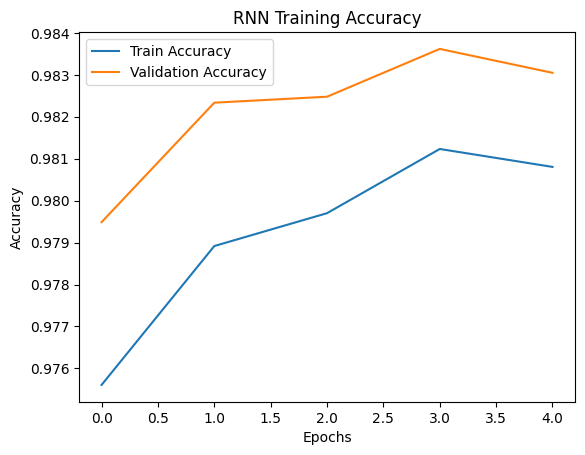

In [15]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("RNN Training Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

The graph shows how the model improves over time.

An increase in accuracy indicates successful learning of sequence patterns.

**Step 5: Model Evaluation**

We evaluate the trained model using:
- Accuracy
- Precision
- Recall
- Confusion Matrix

This helps us understand how well the model detects malware.

In [16]:
y_pred = model.predict(X_test)

275/275 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step


In [17]:
y_pred = (y_pred > 0.5).astype(int)

Converting Predictions

Predicted probabilities are converted into binary values using a threshold of 0.5.

-> 0.5 → malware
- ≤0.5 → benign

In [18]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[  74  152]
 [  28 8522]]


The confusion matrix shows:
- True Positives (correct malware detection)
- True Negatives (correct benign detection)
- False Positives (false alarms)
- False Negatives (missed malware)

False negatives are critical in malware detection.

In [19]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.73      0.33      0.45       226
           1       0.98      1.00      0.99      8550

    accuracy                           0.98      8776
   macro avg       0.85      0.66      0.72      8776
weighted avg       0.98      0.98      0.98      8776



Classification Report

The classification report provides:

- Precision: Accuracy of positive predictions
- Recall: Ability to detect actual malware
- F1-score: Balance between precision and recall

Recall is especially important in malware detection.

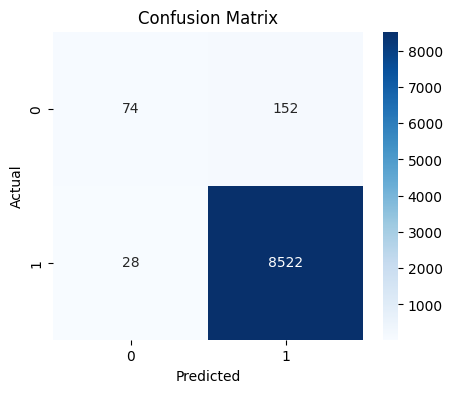

In [20]:
import seaborn as sns

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()